**Integración de datos con Polars**

Objetivos

- Aprender a combinar varios conjuntos de datos.
- Comprender el funcionamiento de un JOIN.
- Obtener información de negocio a partir de distintas fuentes.

In [1]:
import polars as pl

In [2]:
clientes = pl.read_csv("../data/clientes.csv")
productos = pl.read_csv("../data/productos.csv")
ventas = pl.read_csv("../data/ventas.csv")

In [3]:
# Primera integración: añadimos la info del cliente a cada venta
ventas_clientes = ventas.join(
    clientes,
    on="id_cliente",
    how="inner"
)

ventas_clientes.head()

id_venta,fecha,id_cliente,id_producto,cantidad,metodo_pago,descuento,nombre,apellidos,sexo,edad,ciudad,provincia,codigo_postal,fecha_alta,socio,tipo_cliente
i64,str,i64,i64,i64,str,i64,str,str,str,i64,str,str,i64,str,bool,str
1,"""2025-04-07 09:00:00""",276,1,3,"""Tarjeta""",10,"""Ana""","""Vázquez Martín""","""Hombre""",52,"""Pamplona""","""Navarra""",4924,"""2024-06-04""",true,"""Normal"""
2,"""2025-03-12 09:00:00""",34,12,3,"""Tarjeta""",5,"""Jorge""","""Torres Álvarez""","""Hombre""",73,"""Málaga""","""Málaga""",16408,"""2022-07-07""",false,"""Ocasional"""
3,"""2025-08-24 09:00:00""",27,134,3,"""Tarjeta""",0,"""Álvaro""","""Díaz Gómez""","""Mujer""",61,"""Burgos""","""Burgos""",26479,"""2023-07-01""",false,"""Frecuente"""
4,"""2025-08-20 16:00:00""",338,63,1,"""Bizum""",0,"""Carlos""","""Díaz Castro""","""Hombre""",68,"""Barcelona""","""Barcelona""",5567,"""2022-04-15""",false,"""Normal"""
5,"""2025-02-03 21:00:00""",206,68,4,"""Cheque regalo""",0,"""David""","""Gómez Muñoz""","""Mujer""",33,"""Bilbao""","""Bizkaia""",25486,"""2023-09-08""",true,"""Frecuente"""


In [4]:
# Segunda integración: añadimos la información del productoç
ventas_total = ventas_clientes.join(
    productos,
    on="id_producto",
    how="inner"
)

ventas_total.head()

id_venta,fecha,id_cliente,id_producto,cantidad,metodo_pago,descuento,nombre,apellidos,sexo,edad,ciudad,provincia,codigo_postal,fecha_alta,socio,tipo_cliente,nombre_right,categoria,marca,precio,coste
i64,str,i64,i64,i64,str,i64,str,str,str,i64,str,str,i64,str,bool,str,str,str,str,f64,f64
1,"""2025-04-07 09:00:00""",276,1,3,"""Tarjeta""",10,"""Ana""","""Vázquez Martín""","""Hombre""",52,"""Pamplona""","""Navarra""",4924,"""2024-06-04""",true,"""Normal""","""Barra""","""Panadería""","""Casa Tarradellas""",8.49,4.38
2,"""2025-03-12 09:00:00""",34,12,3,"""Tarjeta""",5,"""Jorge""","""Torres Álvarez""","""Hombre""",73,"""Málaga""","""Málaga""",16408,"""2022-07-07""",false,"""Ocasional""","""Lejía""","""Limpieza""","""Pascual""",3.84,2.18
3,"""2025-08-24 09:00:00""",27,134,3,"""Tarjeta""",0,"""Álvaro""","""Díaz Gómez""","""Mujer""",61,"""Burgos""","""Burgos""",26479,"""2023-07-01""",false,"""Frecuente""","""Pipas""","""Snacks""","""Bimbo""",8.24,4.4
4,"""2025-08-20 16:00:00""",338,63,1,"""Bizum""",0,"""Carlos""","""Díaz Castro""","""Hombre""",68,"""Barcelona""","""Barcelona""",5567,"""2022-04-15""",false,"""Normal""","""Atún""","""Conservas""","""Bimbo""",7.92,5.44
5,"""2025-02-03 21:00:00""",206,68,4,"""Cheque regalo""",0,"""David""","""Gómez Muñoz""","""Mujer""",33,"""Bilbao""","""Bizkaia""",25486,"""2023-09-08""",true,"""Frecuente""","""Pipas""","""Snacks""","""Font Vella""",7.08,3.68


In [5]:
# Ahora podemos hacer consultas como:

# ¿Qué provincias realizan más compras?
ventas_total.group_by("provincia").agg(
    pl.len().alias("num_ventas")
).sort(
    "num_ventas",
    descending=True
).head(10)

provincia,num_ventas
str,u32
"""León""",665
"""Salamanca""",663
"""Asturias""",660
"""La Rioja""",644
"""Bizkaia""",640
"""Madrid""",600
"""Valencia""",569
"""Málaga""",567
"""A Coruña""",553


Ahora que hemos integrado clientes, ventas y productos,
podemos utilizar los datos para obtener información de negocio.

Vamos a representar algunos resultados mediante gráficos.

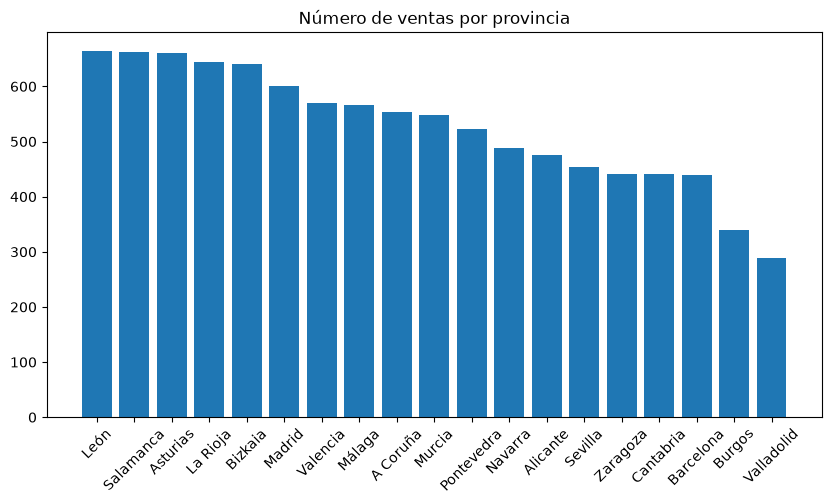

In [6]:
import matplotlib.pyplot as plt

provincias = (
    ventas_total
    .group_by("provincia")
    .agg(pl.len().alias("num_ventas"))
    .sort("num_ventas", descending=True)
)

plt.figure(figsize=(10,5))

plt.bar(
    provincias["provincia"],
    provincias["num_ventas"]
)

plt.xticks(rotation=45)

plt.title("Número de ventas por provincia")

plt.show()

In [7]:
# ¿Qué categorías venden más unidades?
ventas_total.group_by("categoria").agg(
    pl.sum("cantidad").alias("unidades_vendidas")
).sort(
    "unidades_vendidas",
    descending=True
).head(10)

categoria,unidades_vendidas
str,i64
"""Dulces""",2609
"""Snacks""",2168
"""Bebidas""",1893
"""Mascotas""",1879
"""Panadería""",1589
"""Frutas""",1439
"""Bebé""",1431
"""Verduras""",1286
"""Pescados""",1257


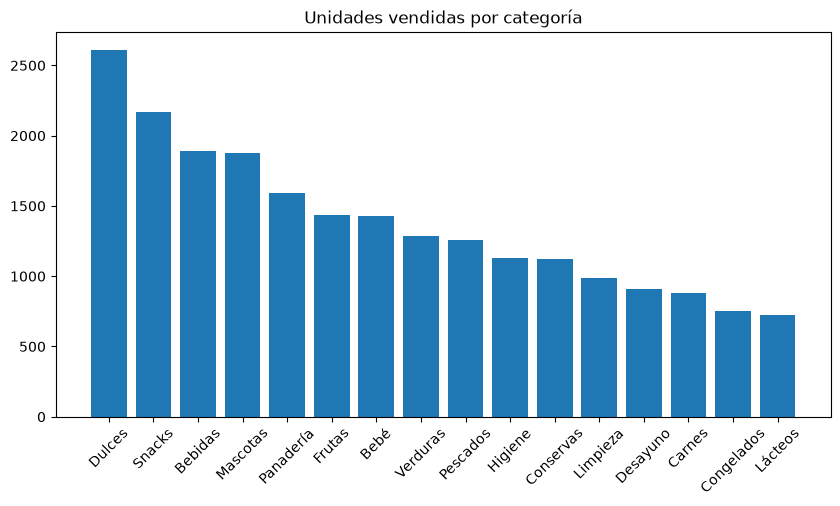

In [8]:
categorias = (
    ventas_total
    .group_by("categoria")
    .agg(
        pl.sum("cantidad").alias("unidades")
    )
    .sort(
        "unidades",
        descending=True
    )
)

plt.figure(figsize=(10,5))

plt.bar(
    categorias["categoria"],
    categorias["unidades"]
)

plt.xticks(rotation=45)

plt.title("Unidades vendidas por categoría")

plt.show()

Observa los gráficos anteriores.

- ¿Qué provincia tiene más ventas? 
    Como indica el grafico numero de ventas, visualizamos que la provincia que tiene mas ventas es Leon
- ¿Qué categoría vende más unidades?
    Como indica el grafico unidades vendidas por categoria, la categoria mas vendida en unidades es "Dulces"
- ¿Qué información nos resulta más útil para tomar una decisión?
    Ambas son importantes pero creo que se deberia de priorizar el numero de ventas por provincia, fijandonos en la competencia, y porque nos come terreno.

Escribe una breve conclusión.
    Visualizamos de manera grafica los datos, facil de entender de cara a cualquier usuario  con una simple vista. Obteniendo informacion util para nuestros analisis.

**Ejercicio**

Utilizando el DataFrame ventas_total, responde al menos a cinco preguntas adicionales que consideres interesantes. Añade visualizaciones que den solución a las preguntas.

In [9]:
ventas_detalle = (
    ventas
    .join(
        clientes.select(["id_cliente", "nombre", "apellidos"]),
        on="id_cliente",
        how="left"
    )
    .join(
        productos.select(["id_producto", "nombre"]),
        on="id_producto",
        how="left",
    )
)

ventas_detalle

id_venta,fecha,id_cliente,id_producto,cantidad,metodo_pago,descuento,nombre,apellidos,nombre_right
i64,str,i64,i64,i64,str,i64,str,str,str
1,"""2025-04-07 09:00:00""",276,1,3,"""Tarjeta""",10,"""Ana""","""Vázquez Martín""","""Barra"""
2,"""2025-03-12 09:00:00""",34,12,3,"""Tarjeta""",5,"""Jorge""","""Torres Álvarez""","""Lejía"""
3,"""2025-08-24 09:00:00""",27,134,3,"""Tarjeta""",0,"""Álvaro""","""Díaz Gómez""","""Pipas"""
4,"""2025-08-20 16:00:00""",338,63,1,"""Bizum""",0,"""Carlos""","""Díaz Castro""","""Atún"""
5,"""2025-02-03 21:00:00""",206,68,4,"""Cheque regalo""",0,"""David""","""Gómez Muñoz""","""Pipas"""
…,…,…,…,…,…,…,…,…,…
9996,"""2025-06-03 13:00:00""",301,90,3,"""Tarjeta""",0,"""Ana""","""Sánchez Navarro""","""Mandarina"""
9997,"""2025-08-22 22:00:00""",295,48,3,"""Cheque regalo""",10,"""Sergio""","""Navarro Martínez""","""Frutos secos"""
9998,"""2025-06-14 09:00:00""",43,126,5,"""Tarjeta""",10,"""Alejandro""","""Torres Fernández""","""Brócoli"""


In [10]:
#Mostramos las ventas que han sido con trajeta y los cliente que la han efectuado
ventas_por_cliente = (
    ventas_detalle.filter(pl.col("metodo_pago")=="Tarjeta")
    .group_by(["id_cliente","nombre","apellidos"]).agg(
        pl.len().alias("num_ventas"),
        pl.sum("cantidad").alias("total_cantidad"),
    )

    )
ventas_por_cliente.sort("total_cantidad", descending=True).head(10)

id_cliente,nombre,apellidos,num_ventas,total_cantidad
i64,str,str,u32,i64
112,"""Iván""","""López Navarro""",34,82
498,"""Jorge""","""Torres Sánchez""",34,82
182,"""Miguel""","""Romero Álvarez""",30,78
210,"""Pablo""","""Sánchez López""",33,76
245,"""Julia""","""Álvarez García""",31,75
357,"""Paula""","""López Fernández""",33,74
57,"""Andrea""","""Pérez Pérez""",34,73
69,"""Ana""","""García García""",36,72
440,"""Ana""","""Martín Castro""",27,70


In [11]:
# Mostramos las ventas pagadas con cheque regalo, agrupadas por producto
# e indicando el número de ventas y la cantidad total de unidades vendidas.
ventas_por_productos = (
    ventas_detalle.filter(pl.col("metodo_pago") == "Cheque regalo")
    .group_by(["id_producto", "nombre_right"])
    .agg(
        pl.len().alias("num_ventas"),
        pl.sum("cantidad").alias("total_cantidad"),
    )
)
ventas_por_productos.sort("total_cantidad", descending=True).head(10)

id_producto,nombre_right,num_ventas,total_cantidad
i64,str,u32,i64
120,"""Kiwi""",8,24
59,"""Caramelos""",8,21
126,"""Brócoli""",7,18
74,"""Cebolla""",7,17
150,"""Cerveza""",6,17
63,"""Atún""",6,17
114,"""Salchichas""",5,17
27,"""Frutos secos""",7,16
53,"""Frutos secos""",6,15


In [12]:
#Mostramos las ventas que han tenido algun descuento, agrupadas por cliente y mostrando el numero de ventas, la cantidad total y el descuento total aplicado
ventas_con_descuento = (
    ventas_detalle.filter(pl.col("descuento")>0)
    .group_by(["id_cliente","nombre","apellidos"])
    .agg(
        pl.len().alias("num_ventas"),
        pl.sum("cantidad").alias("total_cantidad"),
        pl.sum("descuento").alias("total_descuento")
    )
)
ventas_con_descuento

id_cliente,nombre,apellidos,num_ventas,total_cantidad,total_descuento
i64,str,str,u32,i64,i64
178,"""Carlos""","""Gómez Martínez""",2,5,10
476,"""Iván""","""Romero Martínez""",7,17,110
395,"""Paula""","""Martín Martín""",2,7,15
222,"""Sara""","""Ruiz Moreno""",9,19,80
122,"""Miguel""","""Ortega Moreno""",2,3,20
…,…,…,…,…,…
483,"""Sergio""","""Martínez Martín""",9,21,70
482,"""Álvaro""","""Fernández Martínez""",7,16,90
338,"""Carlos""","""Díaz Castro""",5,8,50


In [13]:
#Mostramos quienes son los clientes que mas compran el mismo producto
ventas_cliente_producto = (
    ventas_detalle.group_by(["id_cliente","nombre","apellidos","id_producto","nombre_right"]).agg(
        pl.len().alias("num_ventas"))
).sort("num_ventas", descending=True).head(10)
ventas_cliente_producto

id_cliente,nombre,apellidos,id_producto,nombre_right,num_ventas
i64,str,str,i64,str,u32
255,"""Marta""","""Gómez Ruiz""",65,"""Plátano""",4
41,"""Carmen""","""Castro Pérez""",36,"""Verduras congeladas""",4
112,"""Iván""","""López Navarro""",106,"""Galletas""",3
354,"""Carmen""","""Vázquez López""",72,"""Atún""",3
182,"""Miguel""","""Romero Álvarez""",128,"""Pasta de dientes""",3
313,"""Sofía""","""Álvarez Muñoz""",133,"""Turrón""",3
299,"""Marta""","""Gómez Navarro""",123,"""Pipas""",3
268,"""Iván""","""Díaz Muñoz""",3,"""Detergente""",3
129,"""Marta""","""Castro Muñoz""",149,"""Pañales""",3


In [14]:
#Mostramos lo que mas compra nuestro cliente con mas compras realizadas
compras_jorge = ventas_detalle.filter(pl.col("id_cliente")==498).group_by(["id_producto","nombre_right"],).agg(
    pl.len().alias("num_ventas"),
    pl.sum("cantidad").alias("total_cantidad"),
    pl.sum("descuento").alias("total_descuento")
)
compras_jorge.sort("total_cantidad", descending=True).head(10)

id_producto,nombre_right,num_ventas,total_cantidad,total_descuento
i64,str,u32,i64,i64
104,"""Pan Integral""",2,8,5
84,"""Zumo""",1,5,0
65,"""Plátano""",2,5,5
59,"""Caramelos""",2,5,0
138,"""Chicles""",2,5,0
149,"""Pañales""",1,4,0
21,"""Uva""",1,4,20
117,"""Calamares""",2,4,5
46,"""Snacks perro""",1,4,0


In [17]:
# Clientes que más unidades compran y mayor descuento acumulan
clientes_compras_descuentos = (
    ventas_detalle
    .group_by(["id_cliente", "nombre", "apellidos"])
    .agg(
        pl.sum("cantidad").alias("total_compras"),
        pl.sum("descuento").alias("total_descuento"),
        pl.len().alias("num_ventas"),
    )
    .sort(
        ["total_compras", "total_descuento"],
        descending=[True, True]
    )
    .head(10)
)

clientes_compras_descuentos

id_cliente,nombre,apellidos,total_compras,total_descuento,num_ventas
i64,str,str,i64,i64,u32
441,"""Julia""","""Fernández Martínez""",127,215,56
372,"""Claudia""","""Fernández Vázquez""",118,180,52
182,"""Miguel""","""Romero Álvarez""",117,180,48
357,"""Paula""","""López Fernández""",116,195,52
203,"""Carmen""","""Díaz Martín""",113,145,49
498,"""Jorge""","""Torres Sánchez""",113,115,48
112,"""Iván""","""López Navarro""",112,145,48
210,"""Pablo""","""Sánchez López""",109,190,50
165,"""Laura""","""Torres Gómez""",108,185,49


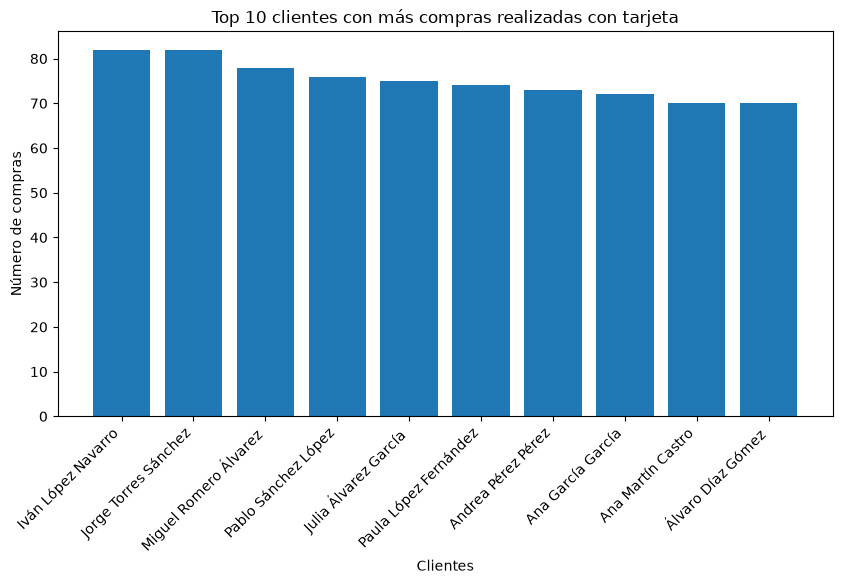

In [15]:
ventas_ordenadas = ventas_por_cliente.sort(
    "total_cantidad",
    descending=True
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    ventas_ordenadas["nombre"] + " " + ventas_ordenadas["apellidos"],
    ventas_ordenadas["total_cantidad"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 clientes con más compras realizadas con tarjeta")
plt.xlabel("Clientes")
plt.ylabel("Número de compras")

plt.show()

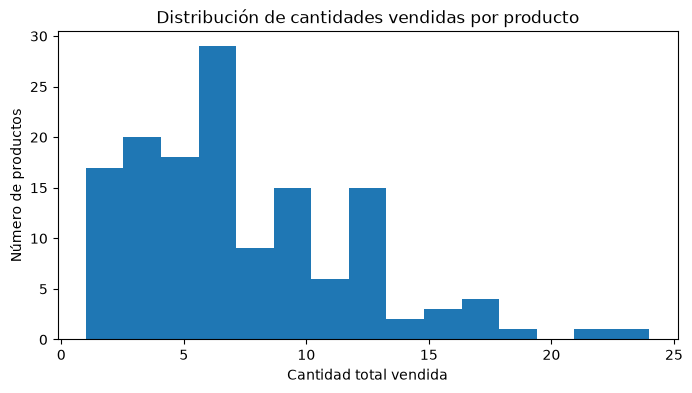

In [16]:
plt.figure(figsize=(8, 4))

plt.hist(
    ventas_por_productos["total_cantidad"].to_list(),
    bins=15,
)

plt.title("Distribución de cantidades vendidas por producto")
plt.xlabel("Cantidad total vendida")
plt.ylabel("Número de productos")

plt.show()